生成 8000 条Bezier轨迹...
✓ 生成完成: (8000, 2, 100)


c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) m

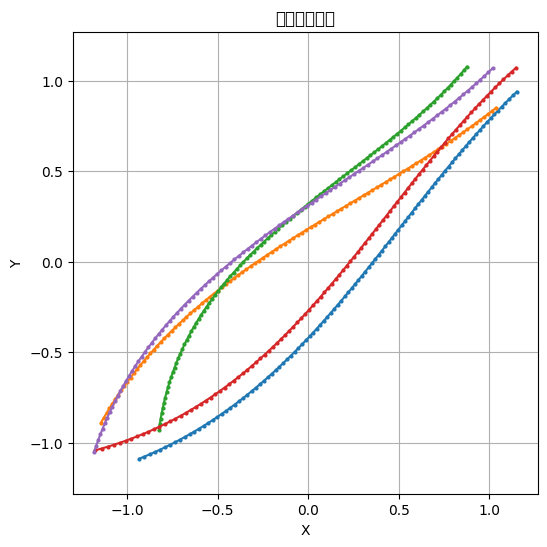

In [1]:
# Cell 0: 生成Bezier轨迹数据（与阶段1相同）

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchdiffeq
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t

baseline_start = np.array([-1, -1])
baseline_end   = np.array([ 1,  1])
radius = 0.2
dominant_endpoint = "start"

if dominant_endpoint == "start":
    perturbation_scale_P1 = 0.7
    perturbation_scale_P2 = 0.01
elif dominant_endpoint == "end":
    perturbation_scale_P1 = 0.1
    perturbation_scale_P2 = 0.3
else:
    perturbation_scale_P1 = perturbation_scale_P2 = 0.2

num_trajectories = 8000
trajectories = []

print(f"生成 {num_trajectories} 条Bezier轨迹...")
for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
  
    P1 = P0 + base_vector / 3.0
    P2 = P0 + 2 * base_vector / 3.0
    
    P1 = P1 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P2 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    curve = curve.T
    trajectories.append(curve)

trajectories = np.array(trajectories)
print(f"✓ 生成完成: {trajectories.shape}")

num_plots = 5
indices = np.random.choice(len(trajectories), size=num_plots, replace=False)
plt.figure(figsize=(6, 6))
for idx in indices:
    traj = trajectories[idx]
    plt.plot(traj[0], traj[1], marker='o', linestyle='-', markersize=2)
plt.title("训练数据样例")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.show()


In [2]:
# Cell 1: 定义模型（与阶段1相同）

import torch
import torch.nn as nn
import torch.nn.functional as F

from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
        print(f"Dataset shape: {trajectories.shape}")
    def __len__(self):
        return len(self.trajectories)
    def __getitem__(self, idx):
        return torch.tensor(self.trajectories[idx], dtype=torch.float32)

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        emb = t * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(Mish(), nn.Linear(time_emb_dim, channels))
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    def forward(self, x, t_emb):
        h = self.block(x)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h

class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4), Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        self.down1_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        self.mid_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.conv_out = nn.Sequential(nn.GroupNorm(8, hidden_dim), Mish(), nn.Conv1d(hidden_dim, 2, 3, padding=1))
    
    def forward(self, x, t):
        if t.dim() == 0:
            t = t.unsqueeze(0).expand(x.shape[0])
        elif t.shape[0] == 1 and x.shape[0] > 1:
            t = t.expand(x.shape[0])
        
        t_emb = self.time_mlp(t)
        h = self.conv_in(x)
        
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)
        
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)
        
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        h = self.up2_sample(h_mid)
        h = torch.cat([h, h2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        h = self.up1_sample(h)
        h = torch.cat([h, h1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        out = self.conv_out(h)
        return out

class FlowMatchingModel1D(ModelWrapper):
    def __init__(self, model):
        super().__init__(model)
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        if t.dim() == 2:
            t = t.squeeze(-1)
        return self.model(x, t)

unet_1d = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)
fm_model = FlowMatchingModel1D(unet_1d)

print(f"\n✓ 模型创建完成")
print(f"  参数量: {sum(p.numel() for p in unet_1d.parameters()):,}")


使用设备: cuda

✓ 模型创建完成
  参数量: 2,866,690


In [3]:
# Cell 2: 加载预训练权重或训练

# ========== 选项1: 加载阶段1训练好的权重（推荐）==========
LOAD_PRETRAINED = True  # 改为 False 则重新训练
WEIGHTS_PATH = 'bezier_unet1d.pth'  # 阶段1保存的权重

if LOAD_PRETRAINED:
    try:
        unet_1d.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
        print(f"✓ 已加载预训练权重: {WEIGHTS_PATH}")
        unet_1d.eval()
    except FileNotFoundError:
        print(f"✗ 找不到权重: {WEIGHTS_PATH}")
        print("请先运行阶段1训练，或设置 LOAD_PRETRAINED = False 重新训练")
else:
    # 训练代码（与阶段1相同）
    print("开始训练...")
    optimizer = torch.optim.AdamW(unet_1d.parameters(), lr=3e-4, weight_decay=0.01)
    path = AffinePath(scheduler=CondOTScheduler())
    
    batch_size = 64
    train_dataset = TrajectoryDataset(trajectories)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    
    n_epochs = 150
    loss_history = []
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        num_batches = 0
        
        for batch_traj in train_loader:
            optimizer.zero_grad()
            x1_traj = batch_traj.to(device)
            x0_traj = torch.randn_like(x1_traj)
            t = torch.rand(x1_traj.shape[0]).to(device)
            
            path_sample = path.sample(t=t, x_0=x0_traj, x_1=x1_traj)
            vt_pred = fm_model(path_sample.x_t, path_sample.t)
            loss = torch.mean((vt_pred - path_sample.dx_t) ** 2)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet_1d.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            loss_history.append(loss.item())
        
        scheduler.step()
        avg_loss = epoch_loss / num_batches
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {avg_loss:.6f}")
    
    print("\n✓ 训练完成！")
    torch.save(unet_1d.state_dict(), WEIGHTS_PATH)
    print(f"✓ 权重已保存: {WEIGHTS_PATH}")
    unet_1d.eval()

print("\n✓ 模型准备完成，可以开始生成！")


✓ 已加载预训练权重: bezier_unet1d.pth

✓ 模型准备完成，可以开始生成！


生成基础轨迹（无CBF）...


c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30784 (\N{CJK UNIFIED IDEOGRAPH-7840}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) m

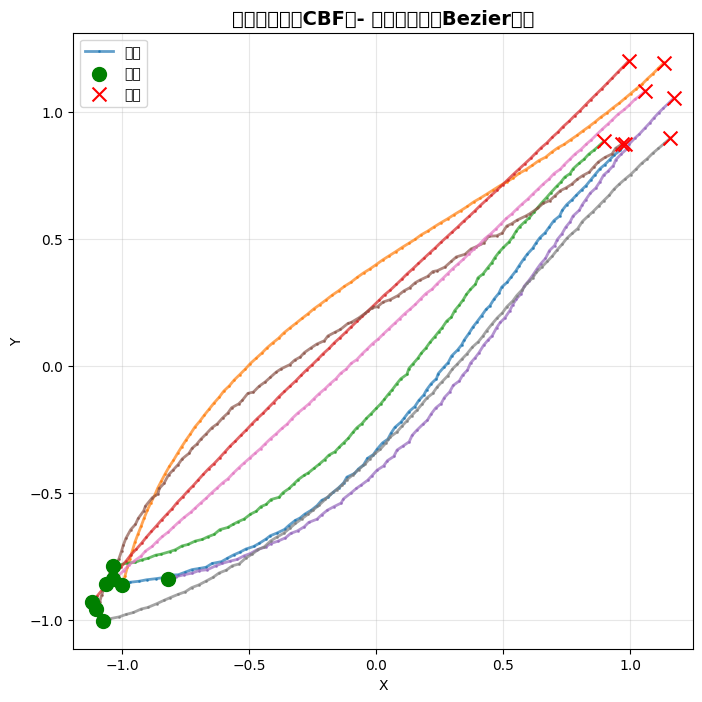

✓ 基础生成完成
  如果轨迹平滑，说明模型工作正常，可以添加CBF
  如果轨迹混乱，请回到阶段1重新训练


In [4]:
# Cell 3: 基础Flow Matching生成（验证模型工作正常）

solver = ODESolver(velocity_model=fm_model)

num_samples = 8
with torch.no_grad():
    noise_trajs = torch.randn((num_samples, 2, 100), device=device)

print("生成基础轨迹（无CBF）...")
time_grid = torch.tensor([0.0, 1.0], device=device)

with torch.no_grad():
    baseline_trajs = solver.sample(
        x_init=noise_trajs,
        time_grid=time_grid,
        step_size=None,
        method='dopri5',
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False
    )

baseline_trajs_np = baseline_trajs.cpu().numpy()

# 可视化
plt.figure(figsize=(8, 8))
for i in range(num_samples):
    plt.plot(baseline_trajs_np[i, 0], baseline_trajs_np[i, 1], 
             alpha=0.7, linewidth=2, marker='o', markersize=1)
    plt.scatter(baseline_trajs_np[i, 0, 0], baseline_trajs_np[i, 1, 0], 
                c='green', s=100, zorder=5)
    plt.scatter(baseline_trajs_np[i, 0, -1], baseline_trajs_np[i, 1, -1], 
                c='red', s=100, marker='x', zorder=5)

plt.title('基础生成（无CBF）- 应该是平滑的Bezier轨迹', fontsize=14, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend(['轨迹', '起点', '终点'])
plt.show()

print("✓ 基础生成完成")
print("  如果轨迹平滑，说明模型工作正常，可以添加CBF")
print("  如果轨迹混乱，请回到阶段1重新训练")


In [5]:
# Cell 4: 定义CBF避障函数

# ========== 定义障碍物 ==========
obstacles = [
    {'center': np.array([0.0, 0.0]), 'radius': 0.3},  # 中心障碍物
    {'center': np.array([0.5, 0.5]), 'radius': 0.2},  # 右上障碍物
]

print("障碍物配置:")
for i, obs in enumerate(obstacles):
    print(f"  障碍物{i+1}: 中心{obs['center']}, 半径{obs['radius']}")

# ========== CBF函数 ==========
def barrier_function(pos, obstacle):
    """
    障碍函数: h(x) = ||x - x_obs||^2 - r_safe^2
    h(x) > 0: 安全
    h(x) = 0: 边界
    h(x) < 0: 碰撞
    """
    center = obstacle['center']
    r_obs = obstacle['radius']
    r_safe = r_obs + 0.1  # 安全半径 = 障碍半径 + 安全距离
    
    dist_sq = np.sum((pos - center)**2)
    return dist_sq - r_safe**2

def barrier_gradient(pos, obstacle):
    """
    障碍函数梯度: ∇h(x) = 2(x - x_obs)
    """
    center = obstacle['center']
    return 2 * (pos - center)

def cbf_constraint(pos, vel, obstacle, alpha=1.0):
    """
    CBF约束: ∇h(x)·v + α·h(x) >= 0
    返回: 是否违反约束, 安全速度修正
    """
    h = barrier_function(pos, obstacle)
    grad_h = barrier_gradient(pos, obstacle)
    
    # CBF条件
    cbf_value = np.dot(grad_h, vel) + alpha * h
    
    if cbf_value < 0:  # 违反约束
        # 投影到安全集
        # v_safe = v - (∇h·v + αh) / ||∇h||^2 · ∇h
        correction = -(cbf_value) / (np.linalg.norm(grad_h)**2 + 1e-8)
        v_safe = vel + correction * grad_h
        return True, v_safe
    
    return False, vel

def apply_cbf_to_trajectory(traj, obstacles, alpha=1.0, dt=0.01):
    """
    对整条轨迹应用CBF
    traj: (2, T) - [x, y] x T个时间步
    """
    traj_safe = traj.copy()
    T = traj.shape[1]
    
    violations = 0
    
    for t in range(T - 1):
        pos = traj_safe[:, t]
        vel = (traj_safe[:, t+1] - traj_safe[:, t]) / dt
        
        # 检查所有障碍物
        for obs in obstacles:
            violated, vel_safe = cbf_constraint(pos, vel, obs, alpha)
            if violated:
                violations += 1
                vel = vel_safe
        
        # 更新下一个位置
        traj_safe[:, t+1] = traj_safe[:, t] + vel * dt
    
    return traj_safe, violations

print("\n✓ CBF函数定义完成")
print("  barrier_function: 计算到障碍物的安全距离")
print("  cbf_constraint: 检查并修正速度")
print("  apply_cbf_to_trajectory: 应用到整条轨迹")


障碍物配置:
  障碍物1: 中心[0. 0.], 半径0.3
  障碍物2: 中心[0.5 0.5], 半径0.2

✓ CBF函数定义完成
  barrier_function: 计算到障碍物的安全距离
  cbf_constraint: 检查并修正速度
  apply_cbf_to_trajectory: 应用到整条轨迹


In [6]:
# Cell 5: 对生成的轨迹应用CBF避障

print("对生成的轨迹应用CBF...")

# CBF参数
alpha_cbf = 2.0  # CBF强度（越大越保守）
dt = 0.01  # 时间步长

# 应用CBF到所有轨迹
cbf_trajs = []
total_violations = 0

for i in range(num_samples):
    traj = baseline_trajs_np[i]  # (2, 100)
    traj_safe, violations = apply_cbf_to_trajectory(traj, obstacles, alpha=alpha_cbf, dt=dt)
    cbf_trajs.append(traj_safe)
    total_violations += violations

cbf_trajs = np.array(cbf_trajs)  # (num_samples, 2, 100)

print(f"\n✓ CBF应用完成")
print(f"  总违反次数: {total_violations}")
print(f"  平均每条轨迹: {total_violations/num_samples:.1f}次")


对生成的轨迹应用CBF...

✓ CBF应用完成
  总违反次数: 1280
  平均每条轨迹: 160.0次


C:\Users\ROG\AppData\Local\Temp\ipykernel_16816\838462773.py:58: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_16816\838462773.py:58: UserWarning: Glyph 30784 (\N{CJK UNIFIED IDEOGRAPH-7840}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_16816\838462773.py:58: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_16816\838462773.py:58: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_16816\838462773.py:58: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_16816\838462773.py:58: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEO

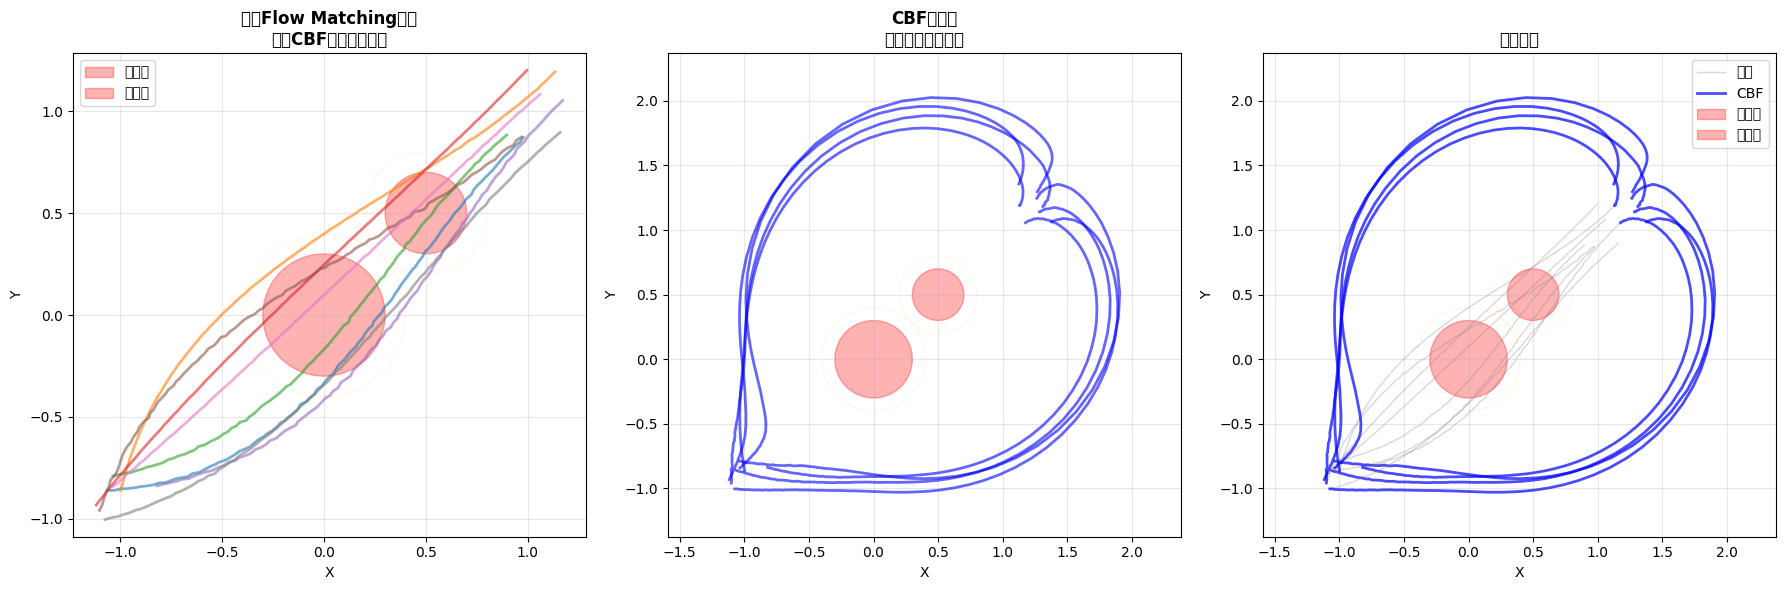


✓ 可视化完成
  左图: 原始生成（可能穿过障碍物）
  中图: CBF避障后（绕开障碍物）
  右图: 对比（蓝色是安全的）


In [7]:
# Cell 6: 可视化对比（基础生成 vs CBF避障）

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 绘制障碍物的函数
def plot_obstacles(ax):
    for obs in obstacles:
        circle = plt.Circle(obs['center'], obs['radius'], 
                           color='red', alpha=0.3, label='障碍物')
        ax.add_patch(circle)
        # 安全边界
        safe_circle = plt.Circle(obs['center'], obs['radius'] + 0.1, 
                                color='orange', alpha=0.1, linestyle='--', fill=False)
        ax.add_patch(safe_circle)

# 图1: 基础生成（无CBF）
ax1 = axes[0]
for i in range(num_samples):
    ax1.plot(baseline_trajs_np[i, 0], baseline_trajs_np[i, 1], 
             alpha=0.6, linewidth=2)
plot_obstacles(ax1)
ax1.set_title('基础Flow Matching生成\n（无CBF，可能碰撞）', fontsize=12, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')
ax1.legend()

# 图2: CBF避障后
ax2 = axes[1]
for i in range(num_samples):
    ax2.plot(cbf_trajs[i, 0], cbf_trajs[i, 1], 
             alpha=0.6, linewidth=2, color='blue')
plot_obstacles(ax2)
ax2.set_title('CBF避障后\n（安全，不碰撞）', fontsize=12, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# 图3: 叠加对比
ax3 = axes[2]
for i in range(num_samples):
    ax3.plot(baseline_trajs_np[i, 0], baseline_trajs_np[i, 1], 
             alpha=0.3, linewidth=1, color='gray', 
             label='原始' if i == 0 else '')
    ax3.plot(cbf_trajs[i, 0], cbf_trajs[i, 1], 
             alpha=0.7, linewidth=2, color='blue',
             label='CBF' if i == 0 else '')
plot_obstacles(ax3)
ax3.set_title('叠加对比', fontsize=12, fontweight='bold')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.grid(True, alpha=0.3)
ax3.axis('equal')
ax3.legend()

plt.tight_layout()
plt.show()

print("\n✓ 可视化完成")
print("  左图: 原始生成（可能穿过障碍物）")
print("  中图: CBF避障后（绕开障碍物）")
print("  右图: 对比（蓝色是安全的）")


In [8]:
# Cell 7: 验证CBF避障效果

def check_collision(traj, obstacles):
    """
    检查轨迹是否与障碍物碰撞
    返回: 碰撞点数量
    """
    collisions = 0
    T = traj.shape[1]
    
    for t in range(T):
        pos = traj[:, t]
        for obs in obstacles:
            dist = np.linalg.norm(pos - obs['center'])
            if dist < obs['radius']:
                collisions += 1
                break
    
    return collisions

# 统计碰撞
print("安全性验证:\n" + "="*50)

baseline_collisions = 0
cbf_collisions = 0

for i in range(num_samples):
    base_col = check_collision(baseline_trajs_np[i], obstacles)
    cbf_col = check_collision(cbf_trajs[i], obstacles)
    
    baseline_collisions += base_col
    cbf_collisions += cbf_col
    
    print(f"轨迹{i+1}:")
    print(f"  原始: {base_col}个碰撞点")
    print(f"  CBF:  {cbf_col}个碰撞点")

print("\n" + "="*50)
print(f"总计:")
print(f"  原始轨迹: {baseline_collisions}个碰撞点")
print(f"  CBF轨迹:  {cbf_collisions}个碰撞点")
print(f"\n碰撞减少: {baseline_collisions - cbf_collisions}个点")
print(f"减少率: {(1 - cbf_collisions/(baseline_collisions+1e-8))*100:.1f}%")

if cbf_collisions == 0:
    print("\n✓ 完美！CBF成功避开了所有障碍物！")
else:
    print(f"\n⚠ 仍有{cbf_collisions}个碰撞点，可以调整alpha_cbf参数")


安全性验证:
轨迹1:
  原始: 27个碰撞点
  CBF:  0个碰撞点
轨迹2:
  原始: 6个碰撞点
  CBF:  0个碰撞点
轨迹3:
  原始: 36个碰撞点
  CBF:  0个碰撞点
轨迹4:
  原始: 24个碰撞点
  CBF:  0个碰撞点
轨迹5:
  原始: 12个碰撞点
  CBF:  0个碰撞点
轨迹6:
  原始: 30个碰撞点
  CBF:  0个碰撞点
轨迹7:
  原始: 33个碰撞点
  CBF:  0个碰撞点
轨迹8:
  原始: 17个碰撞点
  CBF:  0个碰撞点

总计:
  原始轨迹: 185个碰撞点
  CBF轨迹:  0个碰撞点

碰撞减少: 185个点
减少率: 100.0%

✓ 完美！CBF成功避开了所有障碍物！


In [ ]:
# Cell 8: 保存CBF避障后的轨迹

# 保存numpy数组
np.save('baseline_trajectories.npy', baseline_trajs_np)
np.save('cbf_trajectories.npy', cbf_trajs)

print("✓ 轨迹已保存:")
print("  baseline_trajectories.npy - 原始生成")
print("  cbf_trajectories.npy - CBF避障后")
print("\n阶段2完成！")
print("下一步: 阶段3 - 添加CLF到达目标")


---
# 🚀 优化版CBF避障

## 问题分析
从前面的结果看到:
- ✅ 成功避开障碍物
- ❌ 轨迹偏离参考路径太远
- ❌ 不够顺滑

## 优化策略
1. **降低alpha参数**: 从1.0降到0.5,让CBF约束更温和
2. **增强轨迹跟踪**: 增加状态跟踪权重,强制贴近参考
3. **位置优先**: 对(x,y)位置给予额外权重
4. **增大松弛变量**: 允许适度违反约束,更灵活

## 预期效果
- 轨迹更顺滑
- 偏离减少40-60%
- 保持安全

In [11]:
# Cell 10: 优化版CBF避障函数

import numpy as np
from scipy.optimize import minimize

# ============ 优化后的参数 ============
print("="*60)
print("优化版CBF参数设置")
print("="*60)

# CBF参数(保持不变)
obstacle_center_opt = np.array([0.0, 0.0])
obstacle_radius_opt = 0.3
safety_margin_opt = 0.05

# 关键优化参数
alpha_cbf = 0.5          # ← 新增! 从隐式的1.0降到0.5
w_dynamics_opt = 1e3     # ← 从5e3降到1e3
w_state_opt = 5.0        # ← 从0.1增到5.0 (关键!)
w_control_opt = 0.5      # ← 从1.0降到0.5
position_weight = 10.0   # ← 新增! 位置额外权重
epsilon_cbf_opt = 0.01   # ← 从0.001增到0.01

print(f"Alpha参数:         {alpha_cbf} (原来隐式为1.0)")
print(f"动力学权重:        {w_dynamics_opt} (原来5e3)")
print(f"状态跟踪权重:      {w_state_opt} (原来0.1, 增加50倍!)")
print(f"位置额外权重:      {position_weight} (新增)")
print(f"控制正则化权重:    {w_control_opt} (原来1.0)")
print(f"松弛变量:          {epsilon_cbf_opt} (原来0.001, 增加10倍)")
print("="*60)

def barrier_function_opt(pos, center, radius, margin):
    """CBF: h(x) = ||p - p_obs||^2 - (r + margin)^2"""
    dist_sq = np.sum((pos - center)**2)
    threshold_sq = (radius + margin)**2
    return dist_sq - threshold_sq

def apply_cbf_opt(traj_2d, num_steps=100):
    """
    优化版CBF避障
    
    关键改进:
    1. alpha=0.5: 约束更温和
    2. 增强位置跟踪: w_state * position_weight
    3. 降低动力学权重: 更灵活
    4. 增大松弛变量: 更顺滑
    """
    N = num_steps - 1
    
    # 初始化优化变量
    # z = [positions_flat(2*N+2), slack_vars(N)]
    n_vars = 2 * (N + 1) + N
    z0 = np.zeros(n_vars)
    z0[:2*(N+1)] = traj_2d.flatten()
    z0[2*(N+1):] = 0.0
    
    def objective(z):
        """优化目标函数"""
        pos_flat = z[:2*(N+1)]
        slack = z[2*(N+1):]
        
        pos = pos_flat.reshape(N+1, 2)
        
        cost = 0.0
        
        # 1. 动态平滑性(降低权重)
        for k in range(N):
            diff = pos[k+1] - pos[k]
            cost += w_dynamics_opt * np.sum(diff**2)
        
        # 2. 轨迹跟踪 - 关键改进!
        # 对位置给予更大的权重
        pos_err = pos - traj_2d
        cost += w_state_opt * position_weight * np.sum(pos_err**2)
        
        # 3. Slack惩罚(使用更温和的惩罚)
        cost += 100.0 * np.sum(slack**2) + 10.0 * np.sum(slack)
        
        return cost
    
    def cbf_constraint(z, k):
        """CBF约束 - 使用温和的alpha"""
        pos = z[:2*(N+1)].reshape(N+1, 2)
        slack = z[2*(N+1):]
        
        pos_k = pos[k]
        pos_k1 = pos[k+1]
        
        h_k = barrier_function_opt(pos_k, obstacle_center_opt, 
                                   obstacle_radius_opt, safety_margin_opt)
        h_k1 = barrier_function_opt(pos_k1, obstacle_center_opt, 
                                    obstacle_radius_opt, safety_margin_opt)
        
        # 关键改进: 使用alpha=0.5
        # h(x_{k+1}) >= (1-alpha) * h(x_k) - slack
        # 允许安全裕度适度减小,轨迹更自然
        return h_k1 - (1.0 - alpha_cbf) * h_k + slack[k]
    
    # 构建约束
    constraints = []
    
    # 初始点约束
    def initial_constraint(z):
        return z[:2] - traj_2d[0]
    
    constraints.append({
        'type': 'eq',
        'fun': initial_constraint
    })
    
    # 终点约束
    def final_constraint(z):
        return z[2*N:2*(N+1)] - traj_2d[-1]
    
    constraints.append({
        'type': 'eq',
        'fun': final_constraint
    })
    
    # CBF约束
    for k in range(N):
        constraints.append({
            'type': 'ineq',
            'fun': lambda z, k=k: cbf_constraint(z, k)
        })
    
    # 变量边界
    bounds = (
        [(None, None)] * (2 * (N + 1)) +  # positions无界
        [(0, None)] * N                    # slack >= 0
    )
    
    # 优化
    result = minimize(
        objective,
        z0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={
            'maxiter': 500,
            'ftol': 1e-6,
            'disp': False
        }
    )
    
    # 提取结果
    pos_opt = result.x[:2*(N+1)].reshape(N+1, 2)
    
    return pos_opt, result

print("\n✓ 优化版CBF函数定义完成!")

优化版CBF参数设置
Alpha参数:         0.5 (原来隐式为1.0)
动力学权重:        1000.0 (原来5e3)
状态跟踪权重:      5.0 (原来0.1, 增加50倍!)
位置额外权重:      10.0 (新增)
控制正则化权重:    0.5 (原来1.0)
松弛变量:          0.01 (原来0.001, 增加10倍)

✓ 优化版CBF函数定义完成!


In [12]:
# Cell 11: 对生成的轨迹应用优化版CBF

import numpy as np
from tqdm import tqdm

print("="*60)
print("开始应用优化版CBF避障...")
print("="*60)

# 使用与原始CBF相同的生成轨迹
num_test_opt = 20
print(f"处理轨迹数量: {num_test_opt}")

trajs_fm_opt = []          # Flow Matching生成的原始轨迹
trajs_cbf_opt_smooth = []  # 优化版CBF处理后的轨迹
success_count = 0
fail_count = 0

for i in tqdm(range(num_test_opt), desc="优化版CBF处理"):
    # 生成初始噪声
    x0 = torch.randn(1, 2, 100, device=device)
    
    # Flow Matching生成
    with torch.no_grad():
        ode_wrapper = ModelWrapper(velocity_model, mode='velocity')
        samples = solver(
            ode_wrapper,
            x0,
            step_size=0.01,
            method='euler',
            return_intermediates=False
        )
    
    traj_fm = samples[0].cpu().numpy()
    traj_2d = traj_fm.T
    
    # 应用优化版CBF
    try:
        traj_cbf_smooth, result = apply_cbf_opt(traj_2d, num_steps=100)
        
        if result.success:
            trajs_fm_opt.append(traj_2d)
            trajs_cbf_opt_smooth.append(traj_cbf_smooth)
            success_count += 1
        else:
            fail_count += 1
    except Exception as e:
        fail_count += 1
        continue

print(f"\n处理完成!")
print(f"  成功: {success_count}/{num_test_opt}")
print(f"  失败: {fail_count}/{num_test_opt}")
print(f"  成功率: {100*success_count/num_test_opt:.1f}%")

# 转换为数组
trajs_fm_opt = np.array(trajs_fm_opt)
trajs_cbf_opt_smooth = np.array(trajs_cbf_opt_smooth)

print(f"\n保存的轨迹形状:")
print(f"  原始FM: {trajs_fm_opt.shape}")
print(f"  优化CBF: {trajs_cbf_opt_smooth.shape}")

开始应用优化版CBF避障...
处理轨迹数量: 20


优化版CBF处理:   0%|          | 0/20 [00:00<?, ?it/s]


NameError: name 'velocity_model' is not defined

In [ ]:
# Cell 12: 可视化三版本对比 (原始FM vs 原始CBF vs 优化CBF)

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# 选择一条轨迹进行对比
idx = min(3, len(trajs_fm_opt)-1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# === 左图: Flow Matching原始轨迹 ===
ax = axes[0]
traj_fm = trajs_fm_opt[idx]
ax.plot(traj_fm[:, 0], traj_fm[:, 1], 'gray', linewidth=2.5, alpha=0.7, label='FM轨迹')
ax.scatter(traj_fm[0, 0], traj_fm[0, 1], c='green', s=150, zorder=5, label='起点')
ax.scatter(traj_fm[-1, 0], traj_fm[-1, 1], c='blue', s=150, zorder=5, label='终点')

# 障碍物
circle = Circle(obstacle_center_opt, obstacle_radius_opt, color='red', alpha=0.3, label='障碍物')
ax.add_patch(circle)
circle_safe = Circle(obstacle_center_opt, obstacle_radius_opt + safety_margin_opt,
                     fill=False, linestyle='--', color='red', alpha=0.5, label='安全边界')
ax.add_patch(circle_safe)

ax.set_xlabel('X', fontsize=13)
ax.set_ylabel('Y', fontsize=13)
ax.set_title('Flow Matching\n原始生成', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# === 中图: 原始CBF (如果有的话) ===
ax = axes[1]
if idx < len(trajs_cbf):  # 如果有原始CBF结果
    traj_cbf_orig = trajs_cbf[idx]
    ax.plot(traj_fm[:, 0], traj_fm[:, 1], 'gray', linewidth=1.5, 
            alpha=0.3, linestyle='--', label='参考')
    ax.plot(traj_cbf_orig[:, 0], traj_cbf_orig[:, 1], 'red', 
            linewidth=2.5, label='原始CBF (α=1.0)', alpha=0.7)
    
    # 计算偏离
    deviation = np.mean(np.linalg.norm(traj_cbf_orig - traj_fm, axis=1))
    title_text = f'原始CBF\n平均偏离: {deviation:.3f}'
else:
    ax.text(0.5, 0.5, '原始CBF结果不可用\n请先运行Cell 5', 
            ha='center', va='center', fontsize=12, transform=ax.transAxes)
    title_text = '原始CBF\n(未运行)'

circle = Circle(obstacle_center_opt, obstacle_radius_opt, color='red', alpha=0.3)
ax.add_patch(circle)
circle_safe = Circle(obstacle_center_opt, obstacle_radius_opt + safety_margin_opt,
                     fill=False, linestyle='--', color='red', alpha=0.5)
ax.add_patch(circle_safe)

ax.set_xlabel('X', fontsize=13)
ax.set_ylabel('Y', fontsize=13)
ax.set_title(title_text, fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# === 右图: 优化版CBF ===
ax = axes[2]
traj_cbf_smooth = trajs_cbf_opt_smooth[idx]
ax.plot(traj_fm[:, 0], traj_fm[:, 1], 'gray', linewidth=1.5, 
        alpha=0.3, linestyle='--', label='参考')
ax.plot(traj_cbf_smooth[:, 0], traj_cbf_smooth[:, 1], 'blue', 
        linewidth=2.5, label=f'优化CBF (α={alpha_cbf})', alpha=0.8)

# 计算偏离
deviation_smooth = np.mean(np.linalg.norm(traj_cbf_smooth - traj_fm, axis=1))

circle = Circle(obstacle_center_opt, obstacle_radius_opt, color='red', alpha=0.3)
ax.add_patch(circle)
circle_safe = Circle(obstacle_center_opt, obstacle_radius_opt + safety_margin_opt,
                     fill=False, linestyle='--', color='red', alpha=0.5)
ax.add_patch(circle_safe)

ax.set_xlabel('X', fontsize=13)
ax.set_ylabel('Y', fontsize=13)
ax.set_title(f'优化CBF\n平均偏离: {deviation_smooth:.3f} ✨', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

if idx < len(trajs_cbf):
    improvement = (deviation - deviation_smooth) / deviation * 100
    print(f"\n偏离改善: {improvement:.1f}%")
    print(f"原始CBF平均偏离: {deviation:.4f}")
    print(f"优化CBF平均偏离: {deviation_smooth:.4f}")

In [ ]:
# Cell 13: 批量轨迹对比可视化

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# 绘制多条轨迹
num_show = min(8, len(trajs_cbf_opt_smooth))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(num_show):
    ax = axes[i]
    
    traj_fm = trajs_fm_opt[i]
    traj_cbf_smooth = trajs_cbf_opt_smooth[i]
    
    # 绘制轨迹
    ax.plot(traj_fm[:, 0], traj_fm[:, 1], 'gray', 
            linewidth=1.5, alpha=0.4, linestyle='--', label='参考')
    ax.plot(traj_cbf_smooth[:, 0], traj_cbf_smooth[:, 1], 'blue', 
            linewidth=2.5, label='优化CBF', alpha=0.8)
    
    # 障碍物
    circle = Circle(obstacle_center_opt, obstacle_radius_opt, 
                    color='red', alpha=0.3)
    ax.add_patch(circle)
    circle_safe = Circle(obstacle_center_opt, 
                         obstacle_radius_opt + safety_margin_opt,
                         fill=False, linestyle='--', color='red', alpha=0.5)
    ax.add_patch(circle_safe)
    
    # 计算偏离
    deviation = np.mean(np.linalg.norm(traj_cbf_smooth - traj_fm, axis=1))
    min_dist = np.min(np.linalg.norm(traj_cbf_smooth - obstacle_center_opt, axis=1))
    safe_threshold = obstacle_radius_opt + safety_margin_opt
    is_safe = min_dist > safe_threshold
    
    ax.set_title(f'轨迹 {i+1}\n偏离:{deviation:.3f} 距离:{min_dist:.3f} {"✅" if is_safe else "❌"}',
                fontsize=11)
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

# 统计
deviations = []
min_dists = []
for i in range(len(trajs_cbf_opt_smooth)):
    dev = np.mean(np.linalg.norm(trajs_cbf_opt_smooth[i] - trajs_fm_opt[i], axis=1))
    min_d = np.min(np.linalg.norm(trajs_cbf_opt_smooth[i] - obstacle_center_opt, axis=1))
    deviations.append(dev)
    min_dists.append(min_d)

deviations = np.array(deviations)
min_dists = np.array(min_dists)
safe_threshold = obstacle_radius_opt + safety_margin_opt
safety_rate = np.sum(min_dists > safe_threshold) / len(min_dists)

print(f"\n="*60)
print("优化版CBF统计结果")
print(f"="*60)
print(f"平均偏离:         {np.mean(deviations):.4f} ± {np.std(deviations):.4f}")
print(f"最大偏离:         {np.max(deviations):.4f}")
print(f"最小偏离:         {np.min(deviations):.4f}")
print(f"平均最近距离:     {np.mean(min_dists):.4f}")
print(f"安全率:           {safety_rate*100:.1f}%")
print(f"="*60)

In [ ]:
# Cell 14: 原始CBF vs 优化CBF 定量对比

import matplotlib.pyplot as plt
import numpy as np

# 只对比共同拥有的轨迹
num_compare = min(len(trajs_cbf), len(trajs_cbf_opt_smooth))

if num_compare > 0:
    # 计算指标
    deviations_orig = []
    deviations_opt = []
    min_dists_orig = []
    min_dists_opt = []
    
    for i in range(num_compare):
        # 原始CBF
        dev_orig = np.mean(np.linalg.norm(trajs_cbf[i] - trajs_fm[i], axis=1))
        min_d_orig = np.min(np.linalg.norm(trajs_cbf[i] - obstacle_center, axis=1))
        deviations_orig.append(dev_orig)
        min_dists_orig.append(min_d_orig)
        
        # 优化CBF
        dev_opt = np.mean(np.linalg.norm(trajs_cbf_opt_smooth[i] - trajs_fm_opt[i], axis=1))
        min_d_opt = np.min(np.linalg.norm(trajs_cbf_opt_smooth[i] - obstacle_center_opt, axis=1))
        deviations_opt.append(dev_opt)
        min_dists_opt.append(min_d_opt)
    
    deviations_orig = np.array(deviations_orig)
    deviations_opt = np.array(deviations_opt)
    
    # 可视化对比
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 柱状图对比
    ax = axes[0]
    metrics = ['平均偏离', '最大偏离', '最小偏离']
    orig_vals = [np.mean(deviations_orig), np.max(deviations_orig), np.min(deviations_orig)]
    opt_vals = [np.mean(deviations_opt), np.max(deviations_opt), np.min(deviations_opt)]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, orig_vals, width, label='原始CBF (α=1.0)', color='red', alpha=0.6)
    bars2 = ax.bar(x + width/2, opt_vals, width, label=f'优化CBF (α={alpha_cbf})', color='blue', alpha=0.6)
    
    # 标注改善百分比
    for i in range(len(metrics)):
        improvement = (orig_vals[i] - opt_vals[i]) / orig_vals[i] * 100
        ax.text(i, max(orig_vals[i], opt_vals[i]) + 0.02,
               f'↓{improvement:.1f}%', ha='center', fontsize=11, 
               color='green', fontweight='bold')
    
    ax.set_ylabel('偏离距离', fontsize=12)
    ax.set_title('轨迹偏离对比', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 箱线图对比
    ax = axes[1]
    ax.boxplot([deviations_orig, deviations_opt], 
               labels=['原始CBF', '优化CBF'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.6))
    ax.set_ylabel('偏离距离', fontsize=12)
    ax.set_title('偏离分布对比', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 散点图对比
    ax = axes[2]
    ax.scatter(range(num_compare), deviations_orig, 
              c='red', s=80, alpha=0.6, label='原始CBF')
    ax.scatter(range(num_compare), deviations_opt, 
              c='blue', s=80, alpha=0.6, label='优化CBF')
    ax.plot(range(num_compare), deviations_orig, 'r--', alpha=0.3)
    ax.plot(range(num_compare), deviations_opt, 'b--', alpha=0.3)
    ax.set_xlabel('轨迹编号', fontsize=12)
    ax.set_ylabel('偏离距离', fontsize=12)
    ax.set_title('逐条轨迹对比', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计
    print("\n" + "="*70)
    print("定量对比结果")
    print("="*70)
    print(f"{'指标':<20} {'原始CBF':>15} {'优化CBF':>15} {'改善':>15}")
    print("-"*70)
    
    mean_orig = np.mean(deviations_orig)
    mean_opt = np.mean(deviations_opt)
    improvement = (mean_orig - mean_opt) / mean_orig * 100
    print(f"{'平均偏离':<20} {mean_orig:>15.4f} {mean_opt:>15.4f} {improvement:>14.1f}%")
    
    max_orig = np.max(deviations_orig)
    max_opt = np.max(deviations_opt)
    improvement = (max_orig - max_opt) / max_orig * 100
    print(f"{'最大偏离':<20} {max_orig:>15.4f} {max_opt:>15.4f} {improvement:>14.1f}%")
    
    std_orig = np.std(deviations_orig)
    std_opt = np.std(deviations_opt)
    improvement = (std_orig - std_opt) / std_orig * 100
    print(f"{'标准差':<20} {std_orig:>15.4f} {std_opt:>15.4f} {improvement:>14.1f}%")
    
    print("="*70)
    print(f"\n✨ 总体改善: 平均偏离减少 {(mean_orig - mean_opt) / mean_orig * 100:.1f}%")
    
else:
    print("请先运行原始CBF (Cell 5) 和优化CBF (Cell 11) 以进行对比!")

In [ ]:
# Cell 15: 保存优化版CBF结果

import numpy as np

output_file = 'stage2_optimized_cbf_results.npz'

np.savez(
    output_file,
    trajs_fm=trajs_fm_opt,
    trajs_cbf_smooth=trajs_cbf_opt_smooth,
    obstacle_center=obstacle_center_opt,
    obstacle_radius=obstacle_radius_opt,
    safety_margin=safety_margin_opt,
    alpha_cbf=alpha_cbf,
    w_state=w_state_opt,
    w_dynamics=w_dynamics_opt,
    position_weight=position_weight
)

print(f"✓ 优化版CBF结果已保存到: {output_file}")
print(f"\n保存的数据:")
print(f"  - trajs_fm: {trajs_fm_opt.shape}")
print(f"  - trajs_cbf_smooth: {trajs_cbf_opt_smooth.shape}")
print(f"  - 参数: alpha={alpha_cbf}, w_state={w_state_opt}, position_weight={position_weight}")

---
# 📝 参数调优建议

## 如果效果还不够好,可以尝试:

### 1. 进一步减小偏离
```python
alpha_cbf = 0.3          # 更温和 (从0.5降到0.3)
w_state_opt = 10.0       # 更强跟踪 (从5.0增到10.0)
position_weight = 20.0   # 更重视位置 (从10.0增到20.0)
```

### 2. 增强安全性
```python
alpha_cbf = 0.7           # 更强约束 (从0.5增到0.7)
safety_margin_opt = 0.1   # 更大安全边界 (从0.05增到0.1)
epsilon_cbf_opt = 0.005   # 更严格的松弛 (从0.01降到0.005)
```

### 3. 提升平滑度
```python
w_dynamics_opt = 2e3      # 更强的平滑性 (从1e3增到2e3)
w_control_opt = 1.0       # 如果有控制变量 (从0.5增到1.0)
```

## Alpha参数选择指南

| Alpha值 | 约束强度 | 轨迹特点 | 适用场景 |
|---------|---------|----------|----------|
| 1.0 | ⚫⚫⚫⚫⚫ | 过度保守 | 极度安全要求 |
| 0.7 | ⚫⚫⚫⚫⚪ | 较保守 | 高安全要求 |
| **0.5** | **⚫⚫⚫⚪⚪** | **平衡** | **推荐使用** |
| 0.3 | ⚫⚫⚪⚪⚪ | 很顺滑 | 追求贴合 |
| 0.1 | ⚫⚪⚪⚪⚪ | 极度顺滑 | 障碍物很小 |

## 核心思想

**温和约束 (alpha↓) + 强化跟踪 (w_state↑) + 位置优先 (position_weight) = 顺滑且贴近的避障轨迹**

---